<span style="color:#44f;font-weight:bold;">Codes for CNS2025: Lecture 14</span>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Construct input

In [2]:
dth = 0.1 # Angular resolution
ths = np.arange(-np.pi,np.pi,dth) # All θ values
# Generate input
h = np.cos(ths)
h[h<0] = 0
rng = np.random.default_rng(1234)
h = h*2+rng.normal(size=h.size)
dt = 0.01

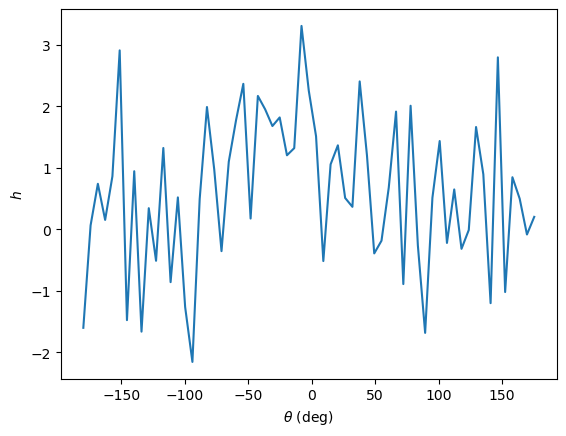

In [3]:
plt.figure()
plt.plot(ths*180/np.pi,h)
plt.ylabel('$h$')
plt.xlabel(r'$\theta$ (deg)')
plt.show()

## Linear recurrent network for selective amplification

\begin{equation*}
\tau_r\frac{dv(\theta)}{dt} = -v(\theta) + h(\theta)+\frac{\lambda_1}{\pi}\int_{-\pi}^{\pi}d\theta'\cos(\theta-\theta')v(\theta')
\end{equation*}

In [4]:
# Recurrent coupling matrix
m = np.cos(np.subtract.outer(ths,ths))
# m = np.cos(ths[:,None]-ths[None,:]) # Same result

In [5]:
# Parameters
lbd1 = 0.9 # Eigenvalue λ₁
# Initial state
v = np.zeros_like(h)

In [6]:
# Iterate until converges to find the steady state
err = 1 # Error
itn = 0 # Number of iteration
while err>1e-10:
    x = h+lbd1*dth*m@v/np.pi
    #x = h+lbd1*dth*np.dot(m,v)/np.pi # Same as above
    dvdt = x-v
    v += dt*dvdt
    err = np.linalg.norm(dvdt) # Use the magnitude of dv/dt as the error
    itn += 1
print(f'Finished after {itn} iterations. {err=:g}')

Finished after 25529 iterations. err=9.99266e-11


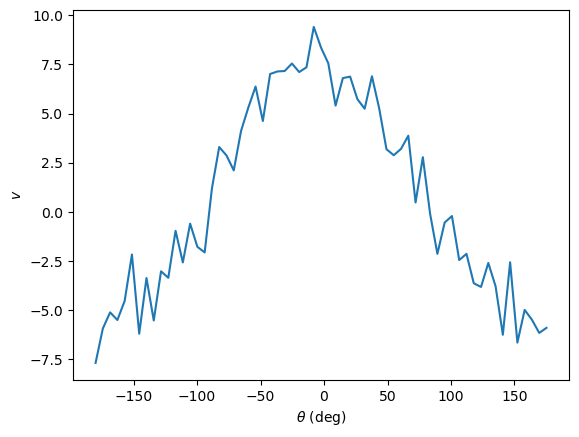

In [7]:
plt.figure()
plt.plot(ths*180/np.pi,v)
plt.ylabel('$v$')
plt.xlabel(r'$\theta$ (deg)')
plt.show()

## Fourier components

In [8]:
def csf(x,mus):
    '''Calculate Cosine and Sine Fourier components

    Parameters
    ==========
    x:    Vector to be decomposed
    mus:  List of component indices

    Returns
    =======
    Magnitudes of components
    '''
    global ths,dth # θs and Δθ
    return np.array([np.sqrt(
        (np.cos(mu*ths)*x).sum()**2+
        (np.sin(mu*ths)*x).sum()**2
    ) for mu in mus])*dth/np.pi

In [9]:
mus = np.arange(10) # μs

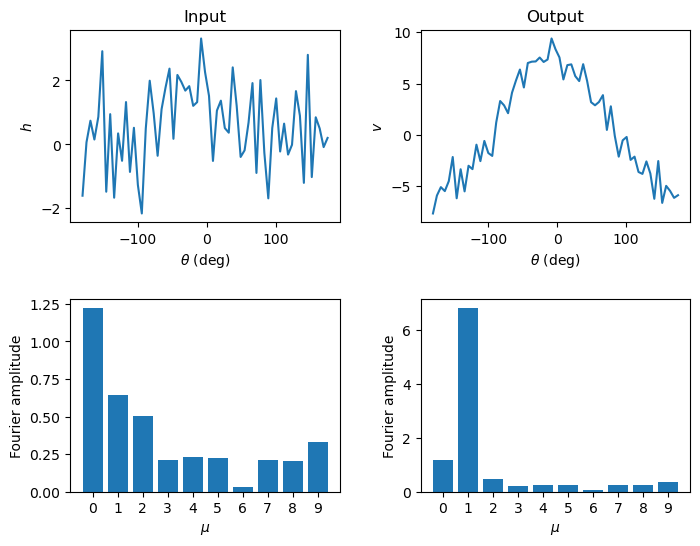

In [10]:
f,aa = plt.subplots(2,2,figsize=(8,6))
f.subplots_adjust(hspace=0.4,wspace=0.3)
for (a,b),(n,t) in zip(aa.T,[('h','Input'),('v','Output')]):
    x = globals()[n]
    a.plot(ths*180/np.pi,x)
    a.set_xlabel(r'$\theta$ (deg)')
    a.set_ylabel(fr'${n}$')
    a.set_title(t)
    b.bar(mus,csf(x,mus))
    b.set_ylabel('Fourier amplitude')
    b.set_xlabel(r'$\mu$')
    b.set_xticks(np.arange(10))
plt.show()

## Nonlinear recurrent network with rectification

\begin{equation*}
\tau_r\frac{dv(\theta)}{dt} = -v(\theta) + \left[h(\theta)+\frac{\lambda_1}{\pi}\int_{-\pi}^{\pi}d\theta'\cos(\theta-\theta')v(\theta')\right]_+
\end{equation*}

In [11]:
# parameters
v = np.zeros_like(h)
lbd1 = 1.9

In [12]:
# iterate until converges
err = 1
itn = 0
while err>1e-10:
    x = h+lbd1*dth*m@v/np.pi
    x[x<0] = 0
    dvdt = x-v
    v += dt*dvdt
    err = np.linalg.norm(dvdt)
    itn += 1
    if itn>100000: break
print(f'Finished after {itn} iterations. {err=:g}')

Finished after 49843 iterations. err=9.99695e-11


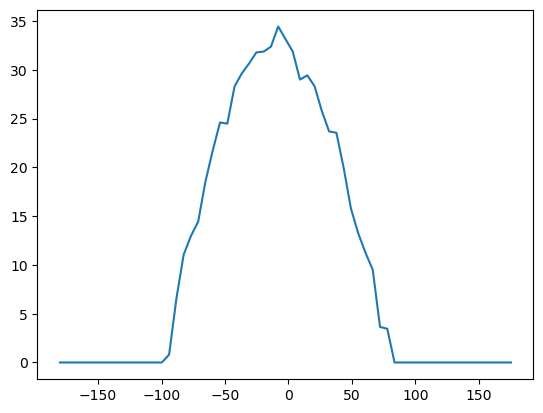

In [13]:
plt.figure()
plt.plot(ths*180/np.pi,v)
plt.show()

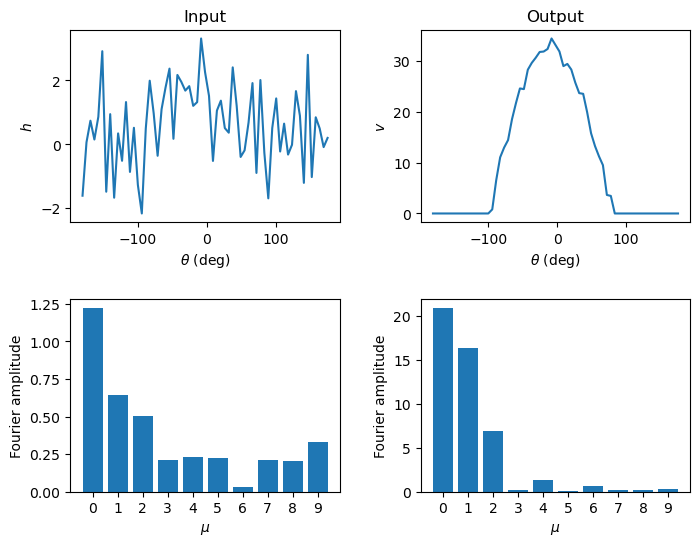

In [14]:
f,aa = plt.subplots(2,2,figsize=(8,6))
f.subplots_adjust(hspace=0.4,wspace=0.3)
for (a,b),(n,t) in zip(aa.T,[('h','Input'),('v','Output')]):
    x = globals()[n]
    a.plot(ths*180/np.pi,x)
    a.set_xlabel(r'$\theta$ (deg)')
    a.set_ylabel(fr'${n}$')
    a.set_title(t)
    b.bar(mus,csf(x,mus))
    b.set_ylabel('Fourier amplitude')
    b.set_xlabel(r'$\mu$')
    b.set_xticks(np.arange(10))
plt.show()

## Input $h$ for homework 

In [15]:
dth = 0.1 # Angle resolution
ths = np.arange(-np.pi,np.pi,dth) # Angles
h0 = np.cos(ths+np.pi/2)-0.8
h0[h0<0] = 0
h1 = np.cos(ths-np.pi/2)-0.82
h1[h1<0] = 0
h = h0+h1
k = np.exp(-np.linspace(-10,10,int(2//dth))**2/10) # Smoothing filter
k /= np.sum(k) # Normalize
h = np.convolve(h,k,'same')

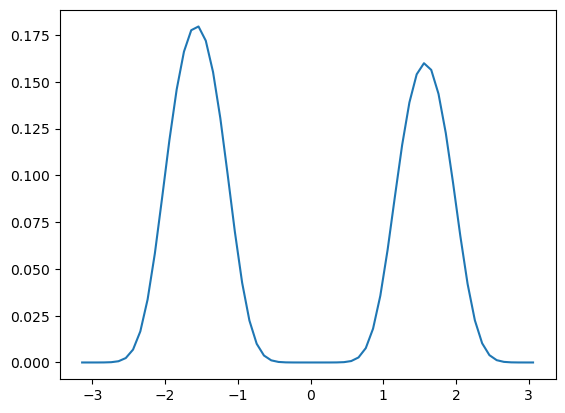

In [16]:
plt.figure()
plt.plot(ths,h)
plt.show()

<hr>
<address style="color:#44f;font-style:italic;font-weight:bold;"><a href="https://cc.tir.tw/wk/2025cns">CNS2025</a></address>